In [6]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'pytorch-forecasting', '--break-system-packages', '-q'],
    capture_output=True, text=True
)
print(result.returncode)
print(result.stdout[-300:] if result.stdout else "")
print(result.stderr[-300:] if result.stderr else "")

0


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



In [1]:
import pytorch_forecasting
print(f"pytorch-forecasting version: {pytorch_forecasting.__version__}")

pytorch-forecasting version: 1.6.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE as TFT_MAE
import warnings
warnings.filterwarnings('ignore')
pl.seed_everything(42)

DATA = Path('../data/processed')
FIGURES = Path('../outputs/figures')

ndvi_amazon_train  = pd.read_csv(DATA / 'ndvi_amazon_train.csv')
ndvi_amazon_test   = pd.read_csv(DATA / 'ndvi_amazon_test.csv')
ndvi_sahel_train   = pd.read_csv(DATA / 'ndvi_sahel_train.csv')
ndvi_sahel_test    = pd.read_csv(DATA / 'ndvi_sahel_test.csv')
sst_atlantic_train = pd.read_csv(DATA / 'sst_atlantic_train.csv')
sst_atlantic_test  = pd.read_csv(DATA / 'sst_atlantic_test.csv')
sst_indian_train   = pd.read_csv(DATA / 'sst_indian_train.csv')
sst_indian_test    = pd.read_csv(DATA / 'sst_indian_test.csv')

for df in [ndvi_amazon_train, ndvi_amazon_test, ndvi_sahel_train, ndvi_sahel_test,
           sst_atlantic_train, sst_atlantic_test, sst_indian_train, sst_indian_test]:
    df['date'] = pd.to_datetime(df['date'])

print("All loaded successfully")

Seed set to 42


All loaded successfully


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Fitting TFT for NDVI Amazon...
  Parameters: 65,316


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


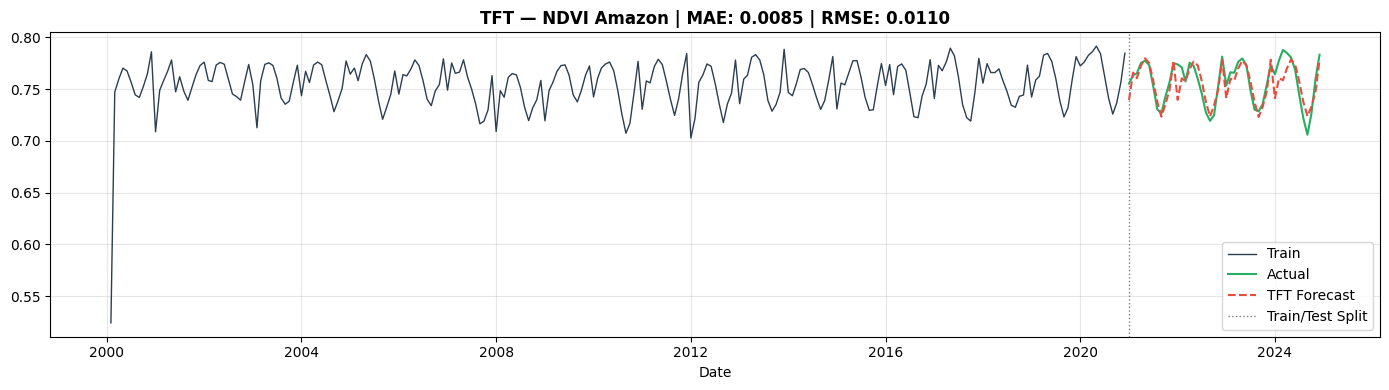

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Fitting TFT for NDVI Sahel...
  Parameters: 65,316


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


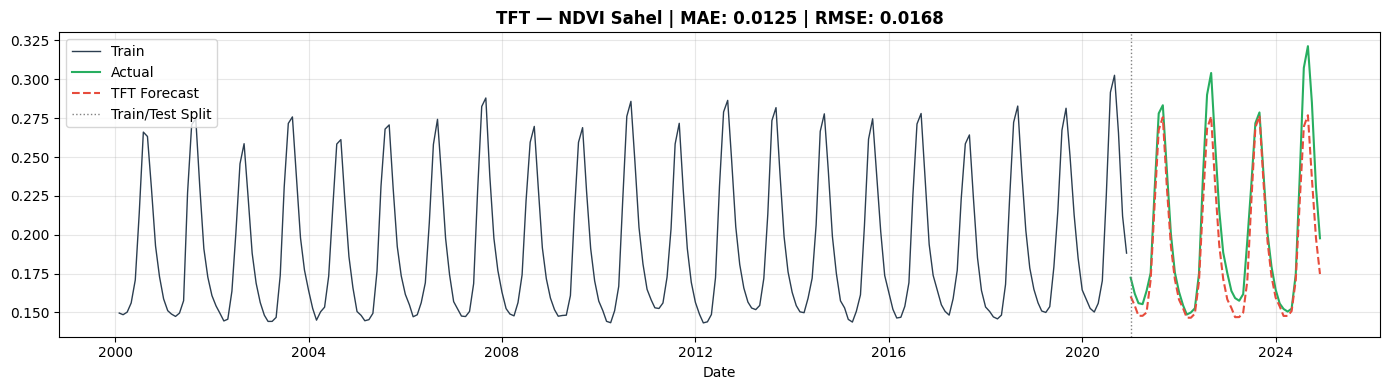


Fitting TFT for SST North Atlantic...
  Parameters: 65,316


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheck

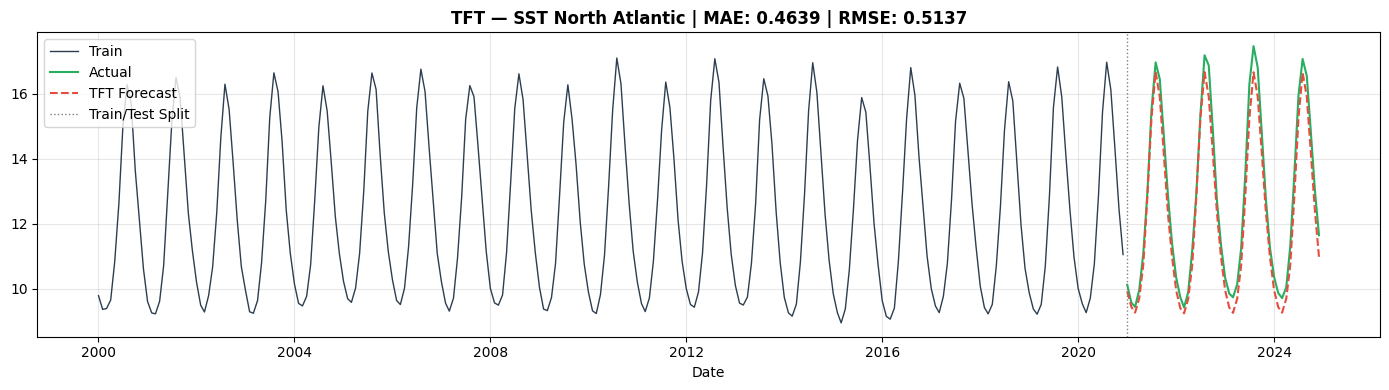


Fitting TFT for SST Indian Ocean...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Parameters: 65,316


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


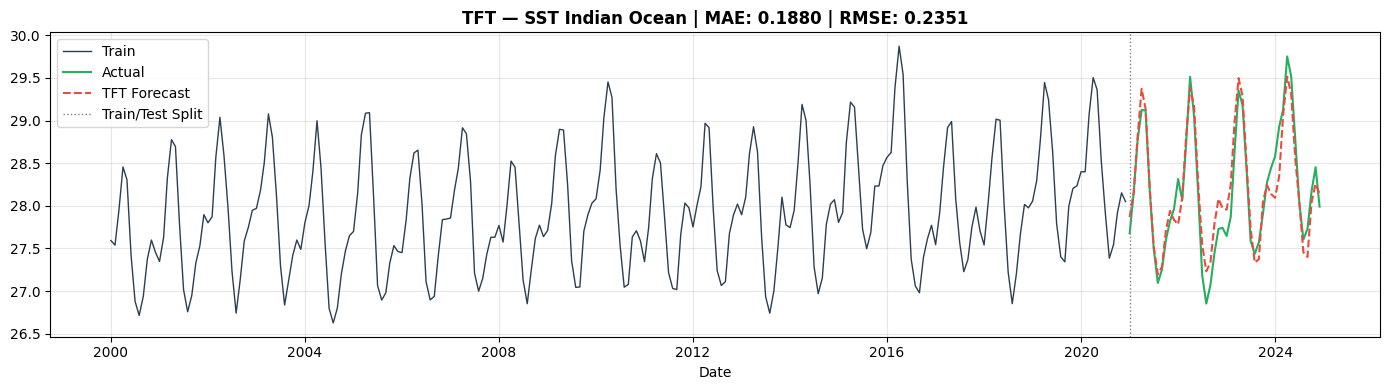


=== TFT Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0085 0.0110
        NDVI Sahel 0.0125 0.0168
SST North Atlantic 0.4639 0.5137
  SST Indian Ocean 0.1880 0.2351


In [3]:
def prepare_tft_data(train, test, value_col):
    full = pd.concat([train, test], ignore_index=True)
    full['time_idx'] = range(len(full))
    full['group'] = 'series_1'
    full['month'] = full['date'].dt.month.astype(str)
    return full, len(train)

def run_tft(train, test, value_col, series_name):
    print(f"\nFitting TFT for {series_name}...")

    full, train_size = prepare_tft_data(train, test, value_col)
    max_encoder_length = 36
    max_prediction_length = len(test)

    training = TimeSeriesDataSet(
        full[full.time_idx < train_size],
        time_idx="time_idx",
        target=value_col,
        group_ids=["group"],
        min_encoder_length=max_encoder_length // 2,
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=["group"],
        time_varying_known_categoricals=["month"],
        time_varying_unknown_reals=[value_col],
        target_normalizer=GroupNormalizer(groups=["group"]),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training, full, predict=True, stop_randomization=True)

    train_loader = training.to_dataloader(train=True, batch_size=32, num_workers=0)
    val_loader   = validation.to_dataloader(train=False, batch_size=32, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=2,
        dropout=0.1,
        hidden_continuous_size=16,
        loss=TFT_MAE(),
        log_interval=10,
        reduce_on_plateau_patience=3,
    )

    print(f"  Parameters: {sum(p.numel() for p in tft.parameters()):,}")

    trainer = pl.Trainer(
        max_epochs=50,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        callbacks=[],
        accelerator='cpu',
    )
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    predictions = tft.predict(
        val_loader, return_y=True, trainer_kwargs=dict(accelerator='cpu'))
    forecast = predictions.output.numpy().flatten()
    actual   = predictions.y[0].numpy().flatten()

    min_len  = min(len(forecast), len(actual), len(test))
    forecast = forecast[:min_len]
    actual   = actual[:min_len]

    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'][:min_len], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'][:min_len], forecast,
            color='#e74c3c', linewidth=1.5, linestyle='--',
            label='TFT Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'TFT — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"fig_tft_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run all four series
results_tft = []

results_tft.append(run_tft(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon'))

results_tft.append(run_tft(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel'))

results_tft.append(run_tft(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic'))

results_tft.append(run_tft(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean'))

results_tft_df = pd.DataFrame(results_tft)
print("\n=== TFT Results ===")
print(results_tft_df.to_string(index=False))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Fitting TFT V2 for NDVI Amazon...
  Parameters: 277,044


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Stopped at epoch: 21


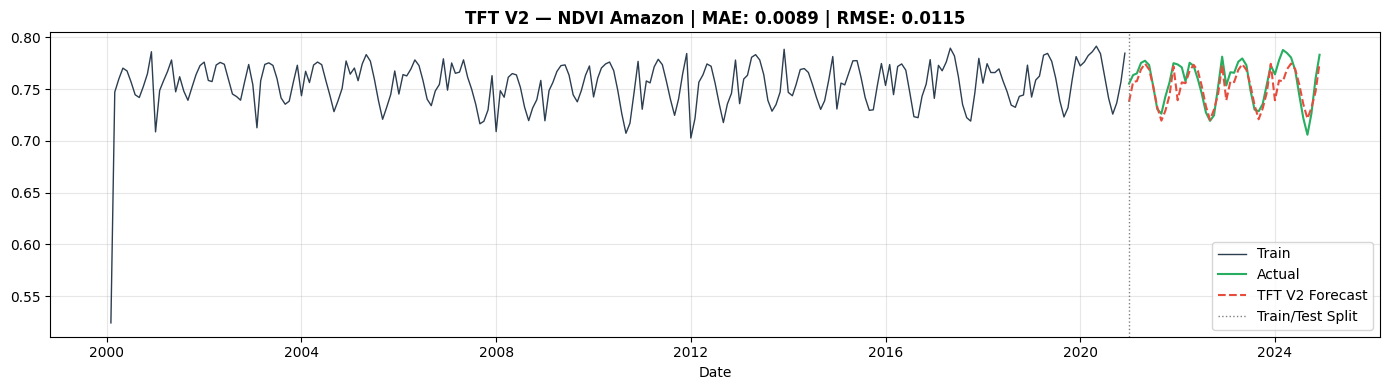


Fitting TFT V2 for NDVI Sahel...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Parameters: 277,044


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Stopped at epoch: 15


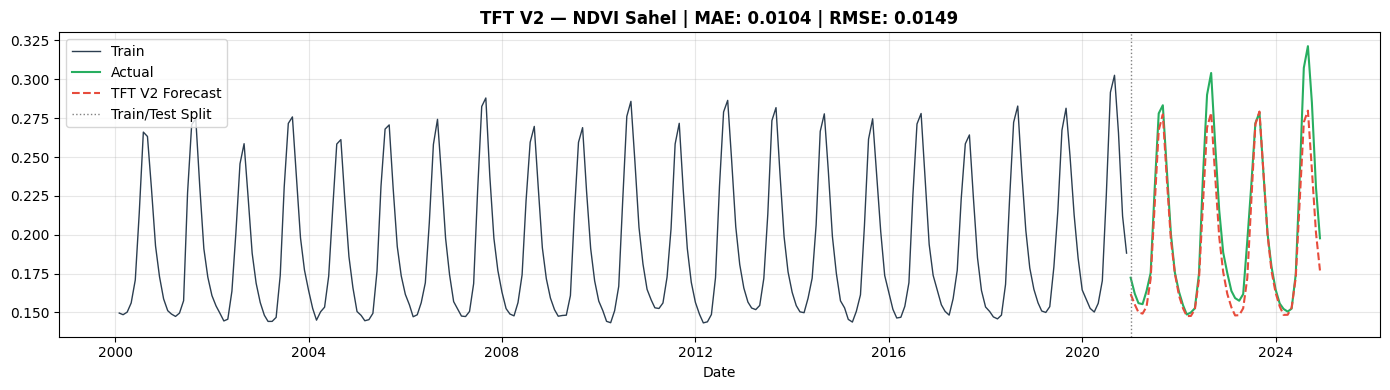

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Fitting TFT V2 for SST North Atlantic...
  Parameters: 277,044


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Stopped at epoch: 13


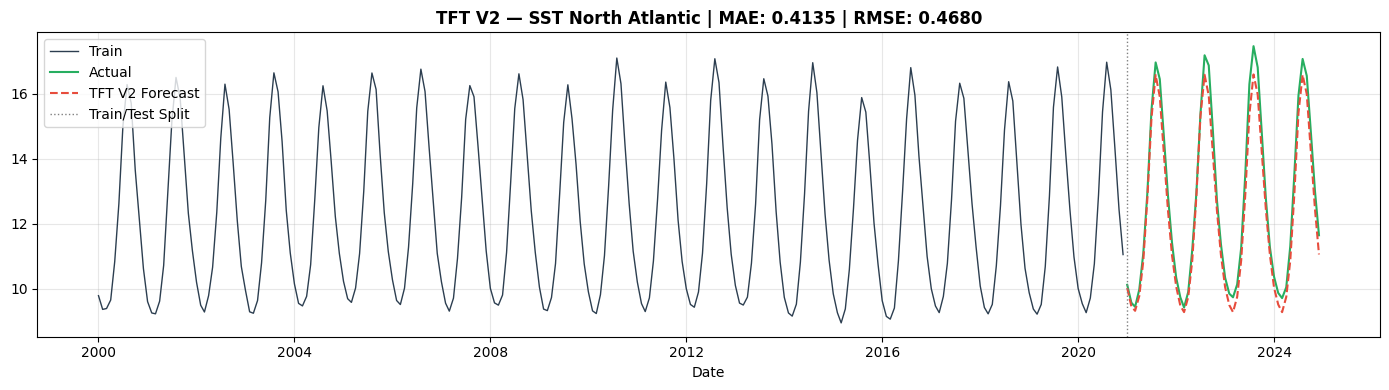


Fitting TFT V2 for SST Indian Ocean...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Parameters: 277,044


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  Stopped at epoch: 46


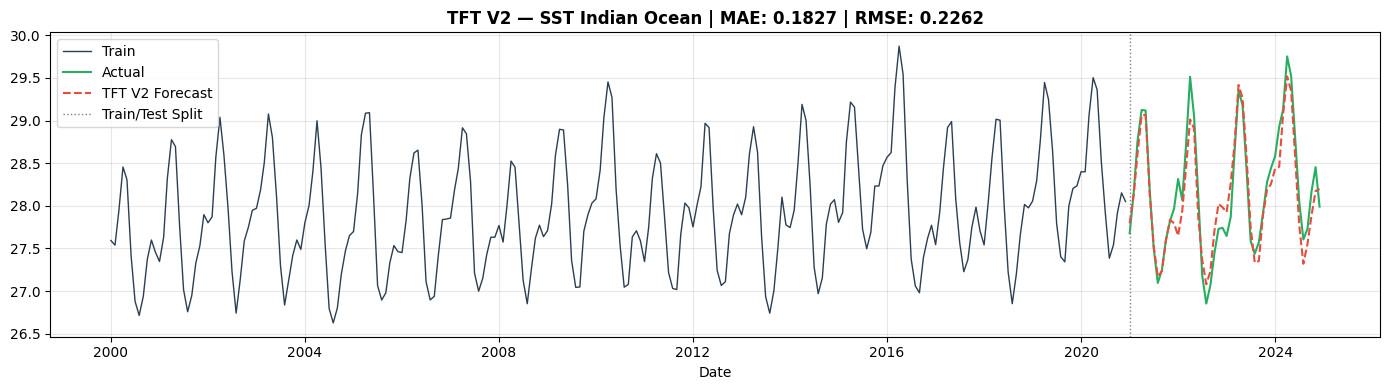


=== TFT V2 Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0089 0.0115
        NDVI Sahel 0.0104 0.0149
SST North Atlantic 0.4135 0.4680
  SST Indian Ocean 0.1827 0.2262


In [4]:
# ============================================================
# TFT V2 — Improved architecture
# Changes from V1:
#   - hidden_size 32 → 64, attention_head_size 2 → 4
#   - hidden_continuous_size 16 → 32
#   - max_epochs 50 → 150 with early stopping (patience=10)
#   - Sinusoidal month encoding added as known real features
#   - dropout reduced 0.1 → 0.05 (more capacity, less regularisation)
# Reference: Lim et al. (2021) IJF 37(4)
# ============================================================

from lightning.pytorch.callbacks import EarlyStopping

def prepare_tft_data_v2(train, test, value_col):
    full = pd.concat([train, test], ignore_index=True)
    full['time_idx'] = range(len(full))
    full['group'] = 'series_1'
    full['month'] = full['date'].dt.month.astype(str)
    full['month_sin'] = np.sin(2 * np.pi * full['date'].dt.month / 12)
    full['month_cos'] = np.cos(2 * np.pi * full['date'].dt.month / 12)
    return full, len(train)

def run_tft_v2(train, test, value_col, series_name):
    print(f"\nFitting TFT V2 for {series_name}...")

    full, train_size = prepare_tft_data_v2(train, test, value_col)
    max_encoder_length = 36
    max_prediction_length = len(test)

    training = TimeSeriesDataSet(
        full[full.time_idx < train_size],
        time_idx="time_idx",
        target=value_col,
        group_ids=["group"],
        min_encoder_length=max_encoder_length // 2,
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=["group"],
        time_varying_known_categoricals=["month"],
        time_varying_known_reals=["relative_time_idx", "month_sin", "month_cos"],
        time_varying_unknown_reals=[value_col],
        target_normalizer=GroupNormalizer(groups=["group"]),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training, full, predict=True, stop_randomization=True)

    train_loader = training.to_dataloader(train=True, batch_size=32, num_workers=0)
    val_loader   = validation.to_dataloader(train=False, batch_size=32, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.05,
        hidden_continuous_size=32,
        loss=TFT_MAE(),
        log_interval=10,
        reduce_on_plateau_patience=5,
    )

    print(f"  Parameters: {sum(p.numel() for p in tft.parameters()):,}")

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        mode='min'
    )

    trainer = pl.Trainer(
        max_epochs=150,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        callbacks=[early_stop],
        accelerator='cpu',
    )

    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
    print(f"  Stopped at epoch: {trainer.current_epoch}")

    predictions = tft.predict(
        val_loader, return_y=True, trainer_kwargs=dict(accelerator='cpu'))
    forecast = predictions.output.numpy().flatten()
    actual   = predictions.y[0].numpy().flatten()

    min_len  = min(len(forecast), len(actual), len(test))
    forecast = forecast[:min_len]
    actual   = actual[:min_len]

    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'][:min_len], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'][:min_len], forecast,
            color='#e74c3c', linewidth=1.5, linestyle='--',
            label='TFT V2 Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'TFT V2 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"fig_tft_v2_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run all four series
results_tft_v2 = []

results_tft_v2.append(run_tft_v2(
    ndvi_amazon_train, ndvi_amazon_test,
    'ndvi_mean', 'NDVI Amazon'))

results_tft_v2.append(run_tft_v2(
    ndvi_sahel_train, ndvi_sahel_test,
    'ndvi_mean', 'NDVI Sahel'))

results_tft_v2.append(run_tft_v2(
    sst_atlantic_train, sst_atlantic_test,
    'sst_mean', 'SST North Atlantic'))

results_tft_v2.append(run_tft_v2(
    sst_indian_train, sst_indian_test,
    'sst_mean', 'SST Indian Ocean'))

results_tft_v2_df = pd.DataFrame(results_tft_v2)
print("\n=== TFT V2 Results ===")
print(results_tft_v2_df.to_string(index=False))